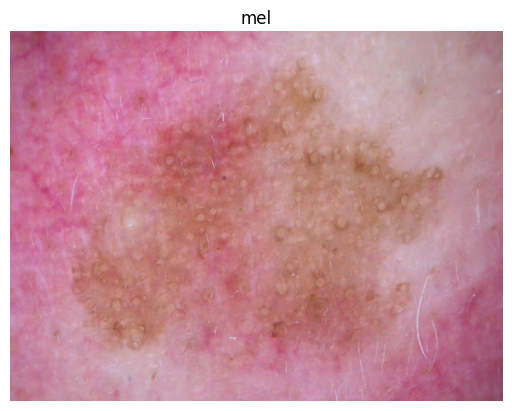

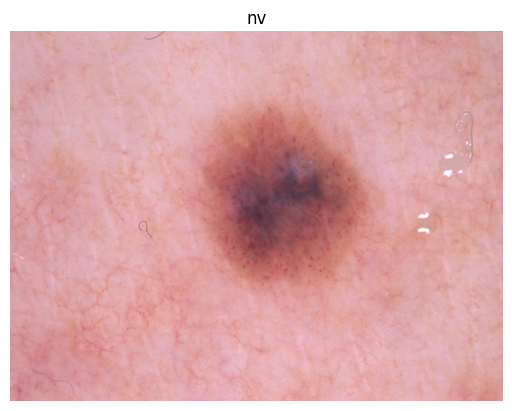

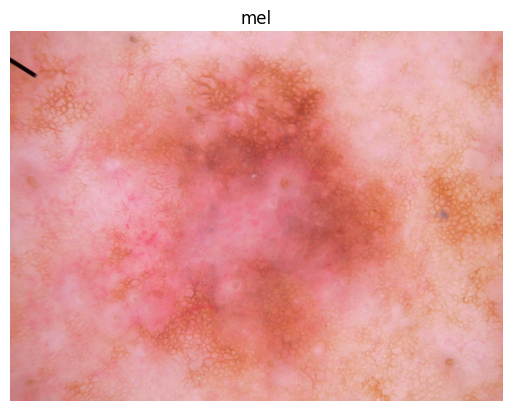

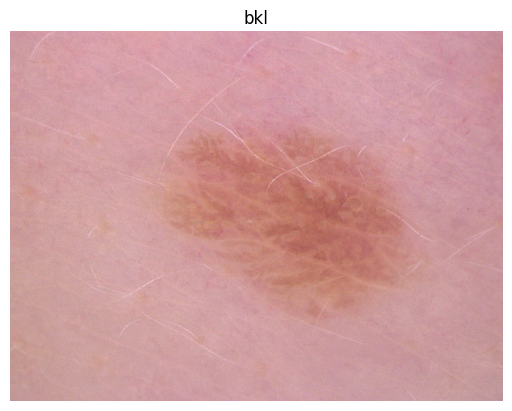

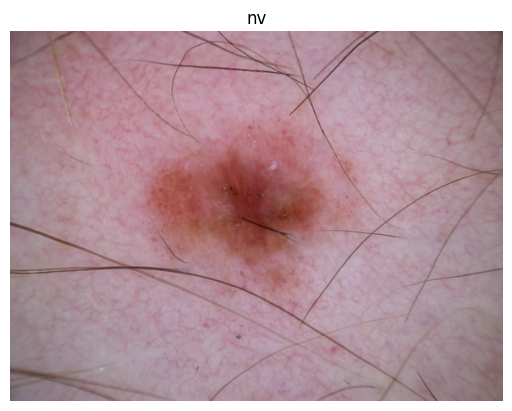

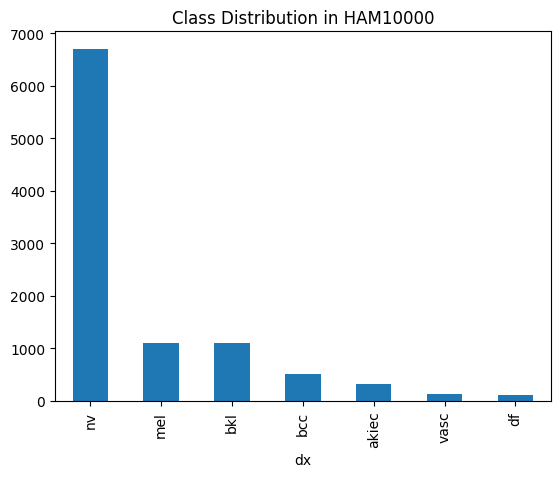

(600, 450)
(600, 450)
(600, 450)
(600, 450)
(600, 450)


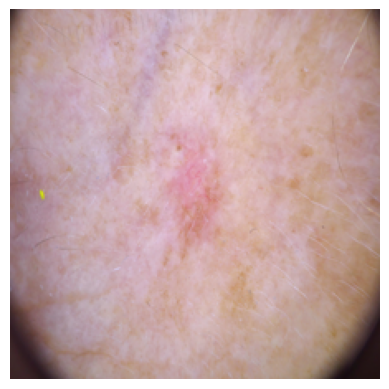

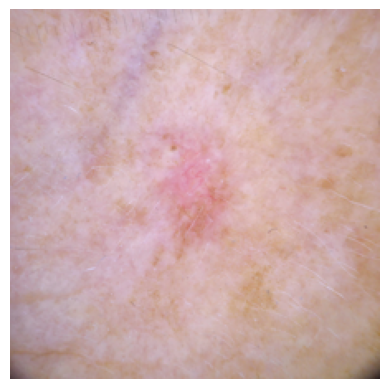

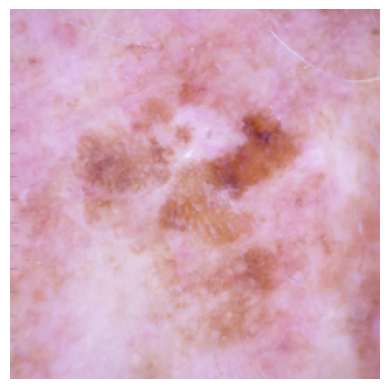

Image path: ../data/HAM10000_images_part_1/ISIC_0027419.jpg
Label (dx): bkl
Numeric label: 2
<class 'PIL.Image.Image'>
2
<class 'PIL.Image.Image'>
2
DATA PIPELINE STATUS
--------------------
Total samples: 10015
Train samples: 8012
Val samples: 2003
Classes: [0, 1, 2, 3, 4, 5, 6]
Batch index: 0
Images shape: torch.Size([2, 3, 224, 224])
Labels: tensor([5, 1])


In [5]:
%run ./01_data_check.ipynb

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms
from torch.utils.data import DataLoader

In [7]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [8]:
tensor_skin_dataset = SimpleSkinDataset(
    dataset_pairs,
    transform=image_transform
)

tensor_train_dataset = DatasetSubset(
    tensor_skin_dataset,
    train_idx
)

train_loader = DataLoader(
    tensor_train_dataset,
    batch_size=2,
    shuffle=True
)

In [9]:
images, labels = next(iter(train_loader))
images.shape, labels

(torch.Size([2, 3, 224, 224]), tensor([4, 5]))

In [10]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Linear(8 * 112 * 112, 7)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [11]:
model = TinyCNN()
outputs = model(images)

outputs.shape

torch.Size([2, 7])

In [12]:
probs = F.softmax(outputs, dim=1)

confidences, predictions = torch.max(probs, dim=1)

confidences, predictions

(tensor([0.1954, 0.1746], grad_fn=<MaxBackward0>), tensor([4, 1]))

In [13]:
for i in range(len(confidences)):
    print(
        f"Sample {i} | "
        f"Predicted class: {predictions[i].item()} | "
        f"Confidence: {confidences[i].item():.2f}"
    )

Sample 0 | Predicted class: 4 | Confidence: 0.20
Sample 1 | Predicted class: 1 | Confidence: 0.17


In [14]:
HIGH_CONF_THRESHOLD = 0.70
MID_CONF_THRESHOLD  = 0.40
LOW_CONF_THRESHOLD  = 0.25

In [15]:
def decide_next_action(confidence):
    if confidence >= HIGH_CONF_THRESHOLD:
        return "SAFE_ADVISORY"
    elif confidence >= MID_CONF_THRESHOLD:
        return "ASK_MEDICAL_QUESTIONS"
    elif confidence >= LOW_CONF_THRESHOLD:
        return "LOW_CONFIDENCE_WARNING"
    else:
        return "ETHICAL_REFUSAL"

In [16]:
for i in range(len(confidences)):
    action = decide_next_action(confidences[i].item())
    print(
        f"Sample {i} | "
        f"Predicted class: {predictions[i].item()} | "
        f"Confidence: {confidences[i].item():.2f} | "
        f"Next action: {action}"
    )

Sample 0 | Predicted class: 4 | Confidence: 0.20 | Next action: ETHICAL_REFUSAL
Sample 1 | Predicted class: 1 | Confidence: 0.17 | Next action: ETHICAL_REFUSAL


In [17]:
QUESTION_CATEGORIES = {
    "BASIC": [
        "How long has the lesion been present?",
        "Has the lesion changed in size or color?",
    ],
    "SYMPTOMS": [
        "Is there itching, pain, or bleeding?",
        "Does the lesion feel rough or scaly?",
    ],
    "RISK_FACTORS": [
        "Do you have a family history of skin cancer?",
        "Have you had significant sun exposure?",
    ]
}

In [18]:
def select_question_category(confidence):
    if confidence >= MID_CONF_THRESHOLD:
        return "BASIC"
    elif confidence >= LOW_CONF_THRESHOLD:
        return "SYMPTOMS"
    else:
        return "RISK_FACTORS"

In [20]:
for i in range(len(confidences)):
    action = decide_next_action(confidences[i].item())

    if action in ["ASK_MEDICAL_QUESTIONS", "LOW_CONFIDENCE_WARNING"]:
        category = select_question_category(confidences[i].item())
        questions = QUESTION_CATEGORIES[category]

        print(f"\nSample {i} | Confidence: {confidences[i].item():.2f}")
        print(f"Question category: {category}")
        for q in questions:
            print(" -", q)

In [21]:
SYMPTOM_IMPACT = {
    "YES": 0.15,
    "NO": -0.05,
    "UNKNOWN": 0.0
}

In [22]:
# Simulated answers for now (later comes real input)
simulated_answers = ["YES", "NO"]

In [23]:
def update_confidence(original_confidence, answers):
    new_confidence = original_confidence

    for ans in answers:
        new_confidence += SYMPTOM_IMPACT.get(ans, 0.0)

    # clamp confidence between 0 and 1
    new_confidence = max(0.0, min(1.0, new_confidence))
    return new_confidence

In [25]:
original_conf = confidences[0].item()
updated_conf = update_confidence(original_conf, simulated_answers)

original_action = decide_next_action(original_conf)
updated_action  = decide_next_action(updated_conf)

print("Original confidence:", round(original_conf, 2))
print("Original action    :", original_action)
print("Updated confidence :", round(updated_conf, 2))
print("Updated action     :", updated_action)

Original confidence: 0.2
Original action    : ETHICAL_REFUSAL
Updated confidence : 0.3
Updated action     : LOW_CONFIDENCE_WARNING


In [26]:
def run_confidence_aware_pipeline(
    image,
    model,
    simulated_answers=None
):
    # Step 1: model inference
    with torch.no_grad():
        output = model(image.unsqueeze(0))  # add batch dim
        probs = F.softmax(output, dim=1)

    confidence, prediction = torch.max(probs, dim=1)
    confidence = confidence.item()
    prediction = prediction.item()

    # Step 2: initial decision
    initial_action = decide_next_action(confidence)

    # Step 3: optional confidence update
    updated_confidence = confidence
    final_action = initial_action

    if initial_action in ["ASK_MEDICAL_QUESTIONS", "LOW_CONFIDENCE_WARNING"] and simulated_answers:
        updated_confidence = update_confidence(confidence, simulated_answers)
        final_action = decide_next_action(updated_confidence)

    return {
        "prediction": prediction,
        "initial_confidence": round(confidence, 2),
        "updated_confidence": round(updated_confidence, 2),
        "initial_action": initial_action,
        "final_action": final_action
    }

In [27]:
# take one tensor image from loader
images, labels = next(iter(train_loader))
sample_image = images[0]

result = run_confidence_aware_pipeline(
    image=sample_image,
    model=model,
    simulated_answers=simulated_answers
)

result

{'prediction': 4,
 'initial_confidence': 0.17,
 'updated_confidence': 0.17,
 'initial_action': 'ETHICAL_REFUSAL',
 'final_action': 'ETHICAL_REFUSAL'}